In [1]:
#============== MIDTERM PRACTICAL PART =====================#
import pandas as pd
import numpy as np
import datetime 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import the information in format mat (matlab)

from scipy.io import loadmat
data = loadmat("use_data.mat")

# Data inside the file
print(data.keys()) #Cleaneddata is the matrix located with the information

#Load the matrix in a variable
cleaneddata = data["cleaneddata"]

dict_keys(['__header__', '__version__', '__globals__', 'cleaneddata'])


In [3]:
# Extract the columns
date = cleaneddata[:, 0].astype(int)
prcp  = cleaneddata[:, 1]

# build the Dataframe
pp = pd.DataFrame({
    "DATE": pd.to_datetime(date.astype(str), format="%Y%m%d"),
    "PRCP": prcp})

# Use the date as index
pp = pp.set_index("DATE")

print(pp.head())
print(pp.columns)

            PRCP
DATE            
1921-01-01   0.0
1921-01-02   0.0
1921-01-03   0.0
1921-01-04   0.0
1921-01-05   9.7
Index(['PRCP'], dtype='object')


In [4]:
#==============Defining the allfitdist function =================#
def allfitdist(data, sortby="BIC"):
   
    import numpy as np
    import pandas as pd
    from scipy import stats

    # ============================================================
    # 1. DATA VALIDATION AND CLEANING
    # ============================================================
    # Convert input to 1D numpy array
    data = np.asarray(data).flatten()

    # Remove NaN values
    data = data[~np.isnan(data)]

    # Ensure dataset is long enough
    if len(data) < 10:
        raise ValueError("Dataset is too short to fit distributions.")

    # ============================================================
    # 2. DISTRIBUTIONS TO BE FITTED
    # ============================================================
    distributions = {
        "norm": stats.norm,
        "lognorm": stats.lognorm,
        "gamma": stats.gamma,
        "weibull_min": stats.weibull_min,
        "weibull_max": stats.weibull_max,
        "gumbel_r": stats.gumbel_r,
        "gumbel_l": stats.gumbel_l,
        "genextreme": stats.genextreme,
        "expon": stats.expon,
        "logistic": stats.logistic,
        "loggamma": stats.loggamma,
        "invgauss": stats.invgauss,
        "pareto": stats.pareto,
        "rayleigh": stats.rayleigh}

    results = []
    fitted_dists = {}
    n = len(data)

    # ============================================================
    # 3. FITTING STANDARD DISTRIBUTIONS
    # ============================================================
    for name, dist in distributions.items():
        try:
            # Fit distribution parameters
            params = dist.fit(data)

            # Log-likelihood
            logL = np.sum(dist.logpdf(data, *params))

            # Number of parameters
            k = len(params)

            # Information criteria
            results.append({
                "name": name,
                "params": params,
                "NLogL": -logL,
                "AIC": 2*k - 2*logL,
                "BIC": k*np.log(n) - 2*logL
            })

            # Store fitted distribution
            fitted_dists[name] = (dist, params)

        except Exception:
            # Skip distribution if fitting fails
            continue

    # ============================================================
    # 4. RESULTS AS DATAFRAME
    # ============================================================
    df = pd.DataFrame(results)
    df = df.sort_values(sortby).reset_index(drop=True)

    return df, fitted_dists

In [5]:
#Cleaning and organising the data

pp['PRCP'] = pd.to_numeric(pp['PRCP'], errors ='coerce')
PrecipAnual= pp.groupby(pp.index.year)['PRCP'].sum()

# Obtain 3 best distributions for the data

D, PD = allfitdist(PrecipAnual, sortby="BIC") #Sorted by the Bayesian Information Criterion (BIC)
top3 = D.head(3)
top1 = top3.iloc[0]["name"]
best_dist, best_params = PD[top1]

# Return periods
periods = [10, 100]
probs = [1 - 1/T for T in periods]

# Compute x(T) for each return period
x_T_values = [best_dist.ppf(p, *best_params) for p in probs]


print(top3)
print("Best distribution:", top1)

       name                                             params       NLogL  \
0  logistic             (534.6524337350944, 99.28397539570175)  692.172169   
1      norm            (541.1228571428571, 177.20913297819715)  692.608257   
2   lognorm  (0.1532396804751291, -607.1236342469924, 1134....  690.630268   

           AIC          BIC  
0  1388.344337  1393.652258  
1  1389.216513  1394.524434  
2  1387.260537  1395.222418  
Best distribution: logistic


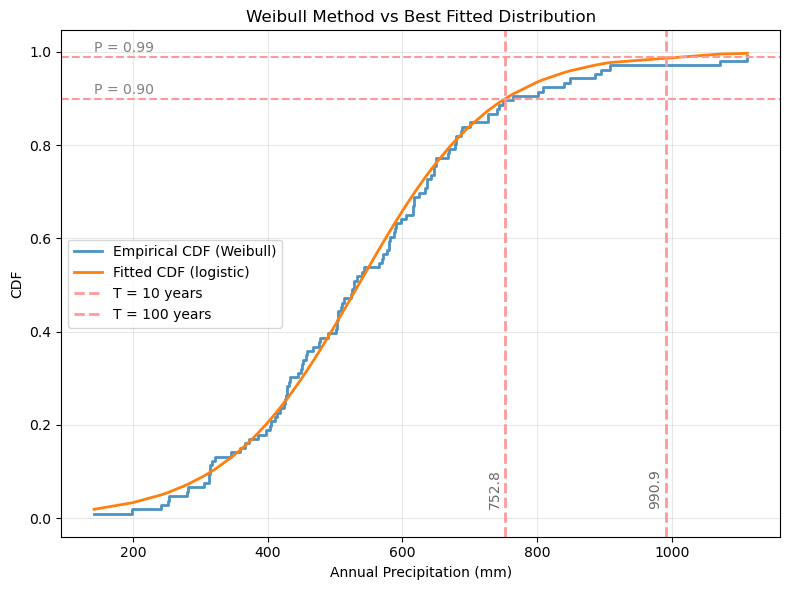

In [6]:
# === Plot the Empirical CDF and the Top1 CDF from Allfitdist ===#
# EMPIRICAL CDF

data_sorted = np.sort(PrecipAnual.values)
n = len(data_sorted)
empirical_cdf = np.arange(1, n+1) / (n+1)

# THEORETICAL CDF OF BEST DISTRIBUTION

theoretical_cdf = best_dist.cdf(data_sorted, *best_params)

# PLOT EMPIRICAL CDF VS BEST FITTED CDF

plt.figure(figsize=(8, 6))

# Empirical CDF
plt.step(data_sorted, empirical_cdf,
         where='post',label='Empirical CDF (Weibull)',
         linewidth=2,alpha=0.8)

# Best fitted distribution CDF
plt.plot(data_sorted, theoretical_cdf,linewidth=2,
         label=f'Fitted CDF ({top1})')

# Vertical dashed lines for T10 and T100
for T, xT in zip(periods, x_T_values):
    plt.axvline(xT, linestyle='--', linewidth=2,
                color='#FF9999',label=f"T = {T} years")

    # Text annotation for x(T)
    plt.text(xT - 5, 0.02, f"{xT:.1f}",
         rotation=90, verticalalignment='bottom',
         horizontalalignment='right', color='#696969')
    
# Horizontal dashed lines at p = 0.90 and p = 0.99
plt.axhline(0.90, linestyle='--', color='#FF9999', linewidth=1.5)
plt.axhline(0.99, linestyle='--', color='#FF9999', linewidth=1.5)

# Text annotations for horizontal lines
plt.text(data_sorted.min(), 0.90 + 0.01, "P = 0.90", color='gray')
plt.text(data_sorted.min(), 0.99 + 0.01, "P = 0.99", color='gray')

plt.xlabel("Annual Precipitation (mm)")
plt.ylabel("CDF")
plt.title("Weibull Method vs Best Fitted Distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Saving process of the graphic 
plt.savefig("CDF_Precip.png", dpi=300, bbox_inches="tight")
plt.show()